# Proyecto Módulo 5  
## Análisis Exploratorio de Datos (EDA)  
**Nombre:** Francisco Belmar  

---

## 📌 Contexto

La empresa ComercioYA desea comprender el comportamiento de sus clientes para mejorar su estrategia comercial.  
Se analizarán variables relacionadas con:

- Compras
- Visitas
- Monto total gastado
- Devoluciones
- Reseñas

El objetivo de esta primera etapa es generar el dataset y realizar una exploración inicial de los datos.

---
## Lección 1: ANÁLISIS EXPLORATORIO DE DATOS

### 1.1 Generación del Dataset

En esta sección generaremos un dataset de 500 clientes de ComercioYA.

Las variables serán:

- **compras:** número de compras realizadas (1–16, con algunos valores atípicos)
- **visitas:** cantidad de visitas al sitio (siempre mayores o iguales que compras)
- **monto_total_clp:** gasto total acumulado en CLP (múltiplos de 500)
- **devoluciones:** número de devoluciones realizadas (0-3)
- **reseñas:** calificación promedio otorgada por el cliente (2.5 a 5.0, 1 decimal)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150

# Semilla única para Francisco Belmar
np.random.seed(777)
n = 500

# Generar datos
compras = np.concatenate([
    np.random.randint(2, 9, int(n * 0.85)),
    np.random.randint(9, 17, int(n * 0.15))
])
np.random.shuffle(compras)

visitas = compras + np.random.randint(0, 5, n)

base_monto = compras * np.random.randint(18000, 32000, n)
ruido = np.random.randint(-5000, 8000, n)
monto_total_clp = np.round((base_monto + ruido) / 500) * 500
monto_total_clp = monto_total_clp.astype(int)

devoluciones = np.random.choice([0, 1, 2, 3], n, p=[0.5, 0.3, 0.15, 0.05])
reseñas = np.round(np.random.uniform(2.5, 5.0, n), 1)

# Crear DataFrame
df = pd.DataFrame({
    'compras': compras,
    'visitas': visitas,
    'monto_total_clp': monto_total_clp,
    'devoluciones': devoluciones,
    'reseñas': reseñas
})

print("✅ Dataset generado correctamente")
df.head()

✅ Dataset generado correctamente


,compras,visitas,monto_total_clp,devoluciones,reseñas
0,5,5,121000,0,2.7
1,4,7,132000,0,3.2
2,5,6,92500,2,4.7
3,6,6,125000,1,3.0
4,8,9,150500,1,4.3


### 1.2 Análisis Inicial de Datos (IDA)

Verificamos tipos de variables, valores faltantes e inconsistencias.

In [2]:
# Información general del dataset
print("📊 INFORMACIÓN DEL DATASET:\n")
df.info()

print("\n🔍 VALORES FALTANTES:\n")
print(df.isnull().sum())

print("\n📈 ESTADÍSTICAS DESCRIPTIVAS:\n")
df.describe()

📊 INFORMACIÓN DEL DATASET:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   compras          500 non-null    int32  
 1   visitas          500 non-null    int32  
 2   monto_total_clp  500 non-null    int64  
 3   devoluciones     500 non-null    int64  
 4   reseñas          500 non-null    float64
dtypes: float64(1), int32(2), int64(2)
memory usage: 15.8 KB

🔍 VALORES FALTANTES:

compras            0
visitas            0
monto_total_clp    0
devoluciones       0
reseñas            0
dtype: int64

📈 ESTADÍSTICAS DESCRIPTIVAS:



,compras,visitas,monto_total_clp,devoluciones,reseñas
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,6.154000,8.096000,153884.000000,0.714000,3.771000
std,3.441216,3.736135,89941.494812,0.849498,0.726881
min,2.000000,2.000000,36000.000000,0.000000,2.500000
25%,4.000000,5.000000,89750.000000,0.000000,3.200000
50%,6.000000,8.000000,133500.000000,0.000000,3.800000
75%,8.000000,10.000000,191625.000000,1.000000,4.400000
max,16.000000,20.000000,497000.000000,3.000000,5.000000


### 1.3 Tipos de Variables

**Variables cuantitativas:**
- `compras` (discreta)
- `visitas` (discreta)
- `monto_total_clp` (continua)
- `devoluciones` (discreta)
- `reseñas` (continua)

**Conclusión inicial:** No se detectaron valores faltantes ni inconsistencias. El dataset está listo para el análisis exploratorio.

---
## Lección 2: CONCEPTOS BÁSICOS DE ESTADÍSTICA DESCRIPTIVA

### 2.1 Medidas de Tendencia Central y Dispersión

In [3]:
# Cálculo de medidas estadísticas
for col in ['compras', 'monto_total_clp']:
    print(f"\n{'='*50}\n{col.upper()}\n{'='*50}")
    print(f"Media:          {df[col].mean():>12,.2f}")
    print(f"Mediana:        {df[col].median():>12,.2f}")
    print(f"Moda:           {df[col].mode()[0]:>12,.2f}")
    print(f"Desv. Estándar: {df[col].std():>12,.2f}")
    print(f"Varianza:       {df[col].var():>12,.2f}")


COMPRAS
Media:                  6.15
Mediana:                6.00
Moda:                   4.00
Desv. Estándar:         3.44
Varianza:              11.84

MONTO_TOTAL_CLP
Media:            153,884.00
Mediana:          133,500.00
Moda:             115,000.00
Desv. Estándar:    89,941.49
Varianza:       8,089,472,488.98


### 2.2 Cuartiles y Percentiles

In [4]:
# Cuartiles
Q1 = df['compras'].quantile(0.25)
Q2 = df['compras'].quantile(0.50)
Q3 = df['compras'].quantile(0.75)
P90 = df['compras'].quantile(0.90)

print(f"Q1 (25%): {Q1}")
print(f"Q2 (50%): {Q2}")
print(f"Q3 (75%): {Q3}")
print(f"P90:      {P90}")

Q1 (25%): 4.0
Q2 (50%): 6.0
Q3 (75%): 8.0
P90:      11.100000000000023


### 2.3 Visualización - Histogramas

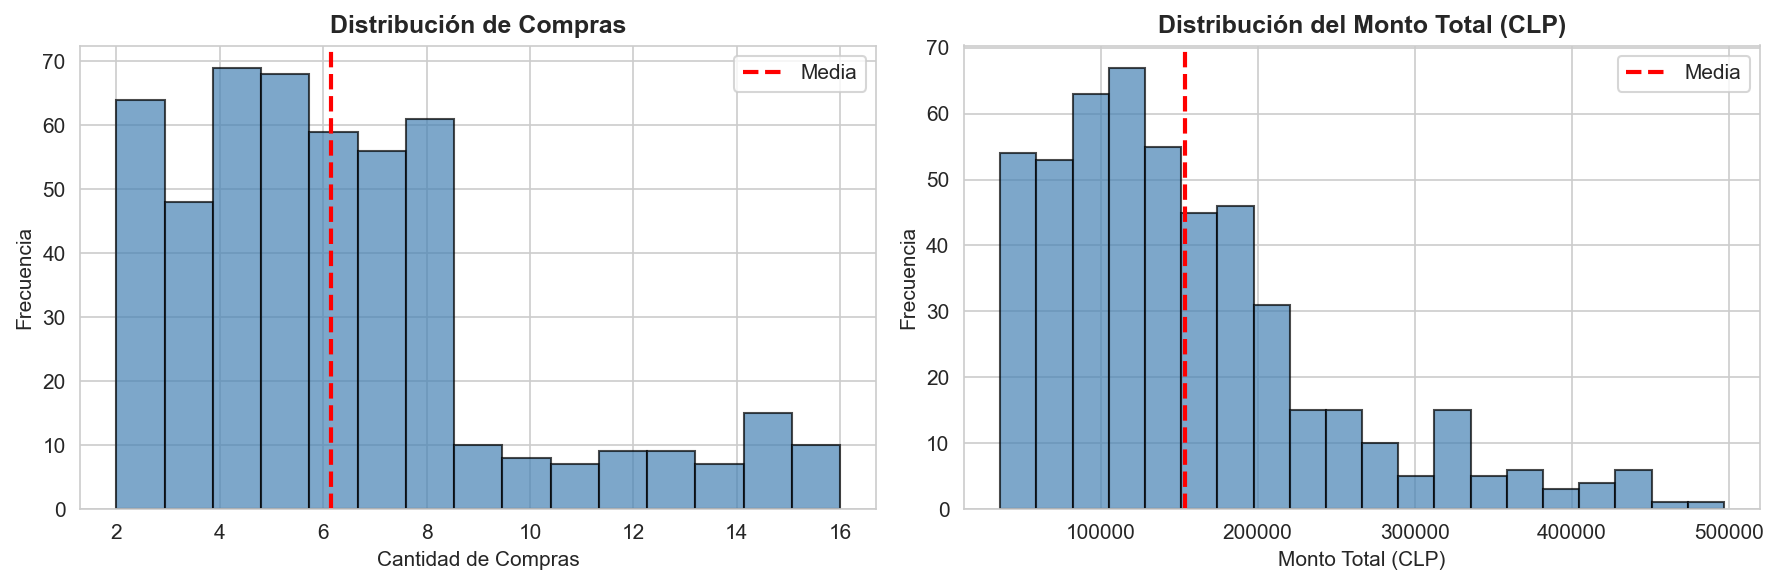

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['compras'], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['compras'].mean(), color='red', linestyle='--', linewidth=2, label='Media')
axes[0].set_title("Distribución de Compras", fontweight='bold')
axes[0].set_xlabel("Cantidad de Compras")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

axes[1].hist(df['monto_total_clp'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(df['monto_total_clp'].mean(), color='red', linestyle='--', linewidth=2, label='Media')
axes[1].set_title("Distribución del Monto Total (CLP)", fontweight='bold')
axes[1].set_xlabel("Monto Total (CLP)")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

plt.tight_layout()
plt.savefig("Histograma_Compras.png", dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Visualización - Boxplots

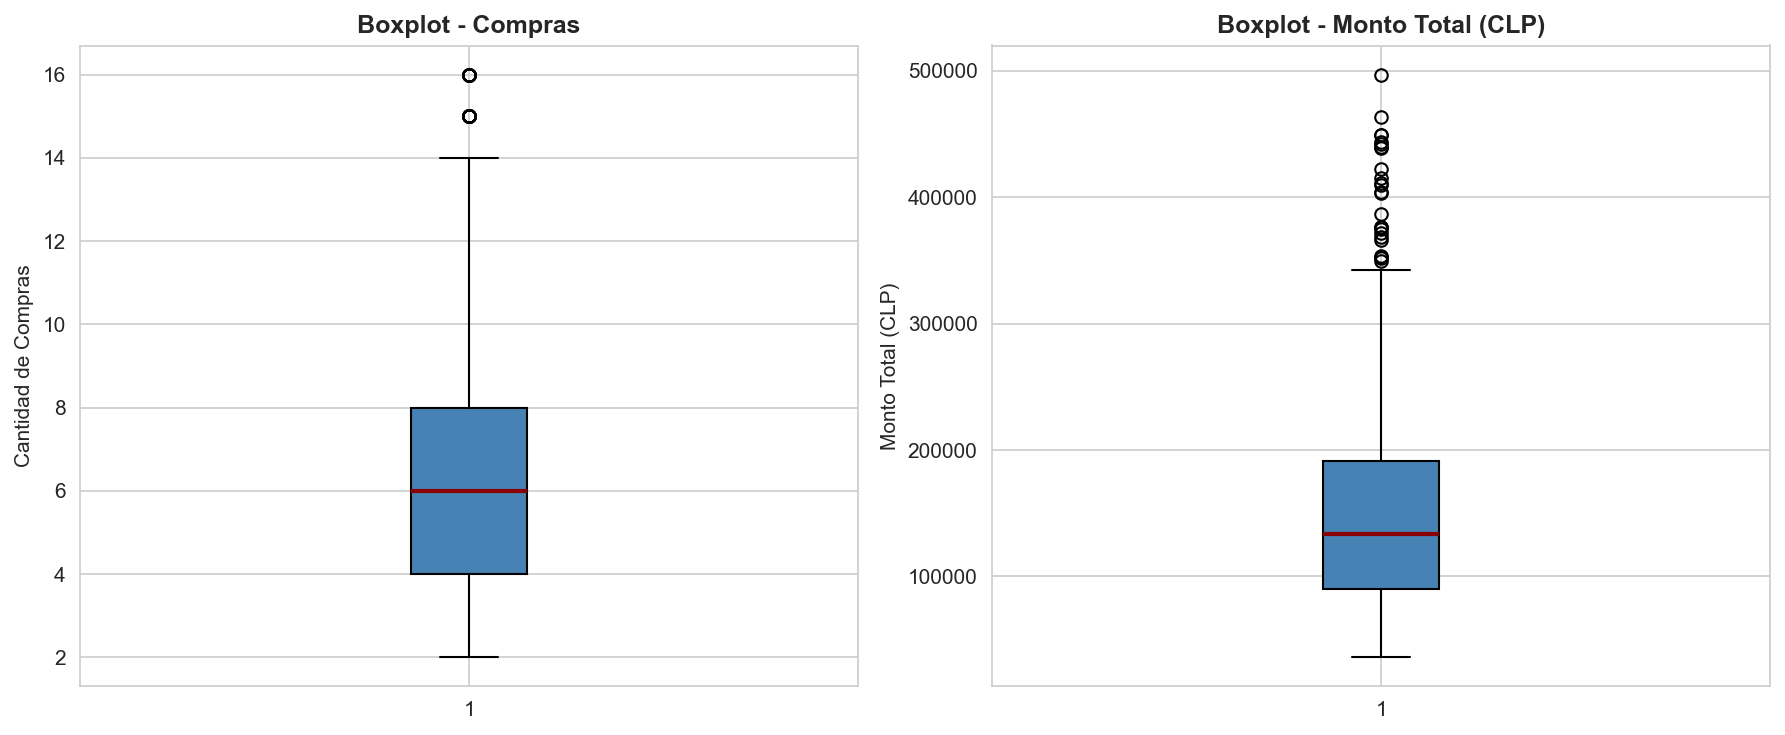

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df['compras'], patch_artist=True, 
                boxprops=dict(facecolor='steelblue'),
                medianprops=dict(color='darkred', linewidth=2))
axes[0].set_title("Boxplot - Compras", fontweight='bold')
axes[0].set_ylabel("Cantidad de Compras")

axes[1].boxplot(df['monto_total_clp'], patch_artist=True,
                boxprops=dict(facecolor='steelblue'),
                medianprops=dict(color='darkred', linewidth=2))
axes[1].set_title("Boxplot - Monto Total (CLP)", fontweight='bold')
axes[1].set_ylabel("Monto Total (CLP)")

plt.tight_layout()
plt.savefig("Boxplot_Compras.png", dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Detección de Valores Atípicos (IQR)

In [7]:
# Método IQR para detectar outliers
Q1 = df['compras'].quantile(0.25)
Q3 = df['compras'].quantile(0.75)
IQR = Q3 - Q1

limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

outliers = df[(df['compras'] < limite_inf) | (df['compras'] > limite_sup)]
print(f"⚠️  Outliers detectados: {len(outliers)} registros")
print(f"   Límite inferior: {limite_inf}")
print(f"   Límite superior: {limite_sup}")

if len(outliers) > 0:
    print("\nRegistros atípicos:")
    print(outliers[['compras', 'monto_total_clp']].head())

⚠️  Outliers detectados: 25 registros
   Límite inferior: -2.0
   Límite superior: 14.0

Registros atípicos:
    compras  monto_total_clp
6        16           439000
15       16           411000
19       15           463500
29       16           293000
35       15           319000


---
## Lección 3: CORRELACIÓN

### 3.1 Matriz de Correlación

In [8]:
corr_matrix = df.corr()
print("📊 MATRIZ DE CORRELACIÓN:\n")
print(corr_matrix)

📊 MATRIZ DE CORRELACIÓN:

                  compras   visitas  monto_total_clp  devoluciones   reseñas
compras          1.000000  0.926747         0.946640      0.026751 -0.051729
visitas          0.926747  1.000000         0.879273      0.019402 -0.065017
monto_total_clp  0.946640  0.879273         1.000000      0.053321 -0.066635
devoluciones     0.026751  0.019402         0.053321      1.000000  0.037819
reseñas         -0.051729 -0.065017        -0.066635      0.037819  1.000000


### 3.2 Visualización - Heatmap

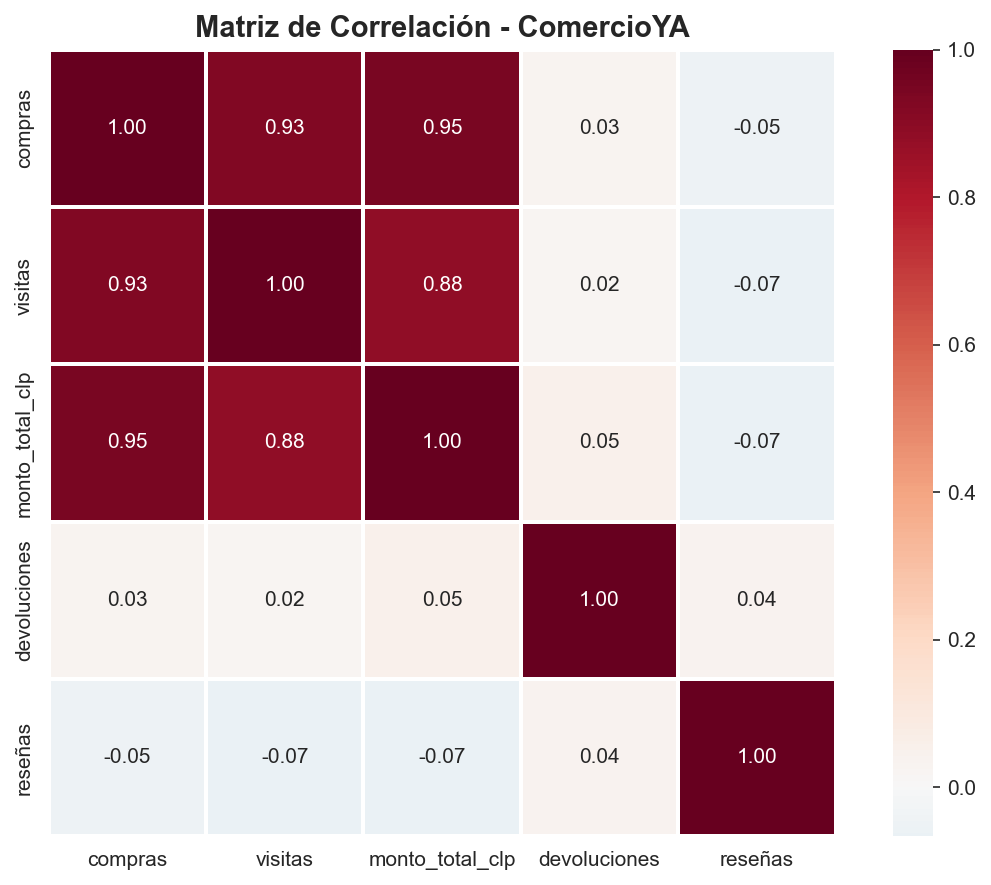

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=1)
plt.title("Matriz de Correlación - ComercioYA", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig("Heatmap_correlacion.png", dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Coeficiente de Pearson

In [10]:
pearson_r, pearson_p = stats.pearsonr(df['compras'], df['monto_total_clp'])

print(f"📈 Correlación de Pearson (compras vs monto_total_clp):")
print(f"   Coeficiente r: {pearson_r:.4f}")
print(f"   P-value:       {pearson_p:.6f}")

if abs(pearson_r) > 0.7:
    print(f"   Interpretación: Correlación FUERTE {'positiva' if pearson_r > 0 else 'negativa'}")
elif abs(pearson_r) > 0.4:
    print(f"   Interpretación: Correlación MODERADA {'positiva' if pearson_r > 0 else 'negativa'}")
else:
    print(f"   Interpretación: Correlación DÉBIL")

📈 Correlación de Pearson (compras vs monto_total_clp):
   Coeficiente r: 0.9466
   P-value:       0.000000
   Interpretación: Correlación FUERTE positiva


### 3.4 Scatterplots

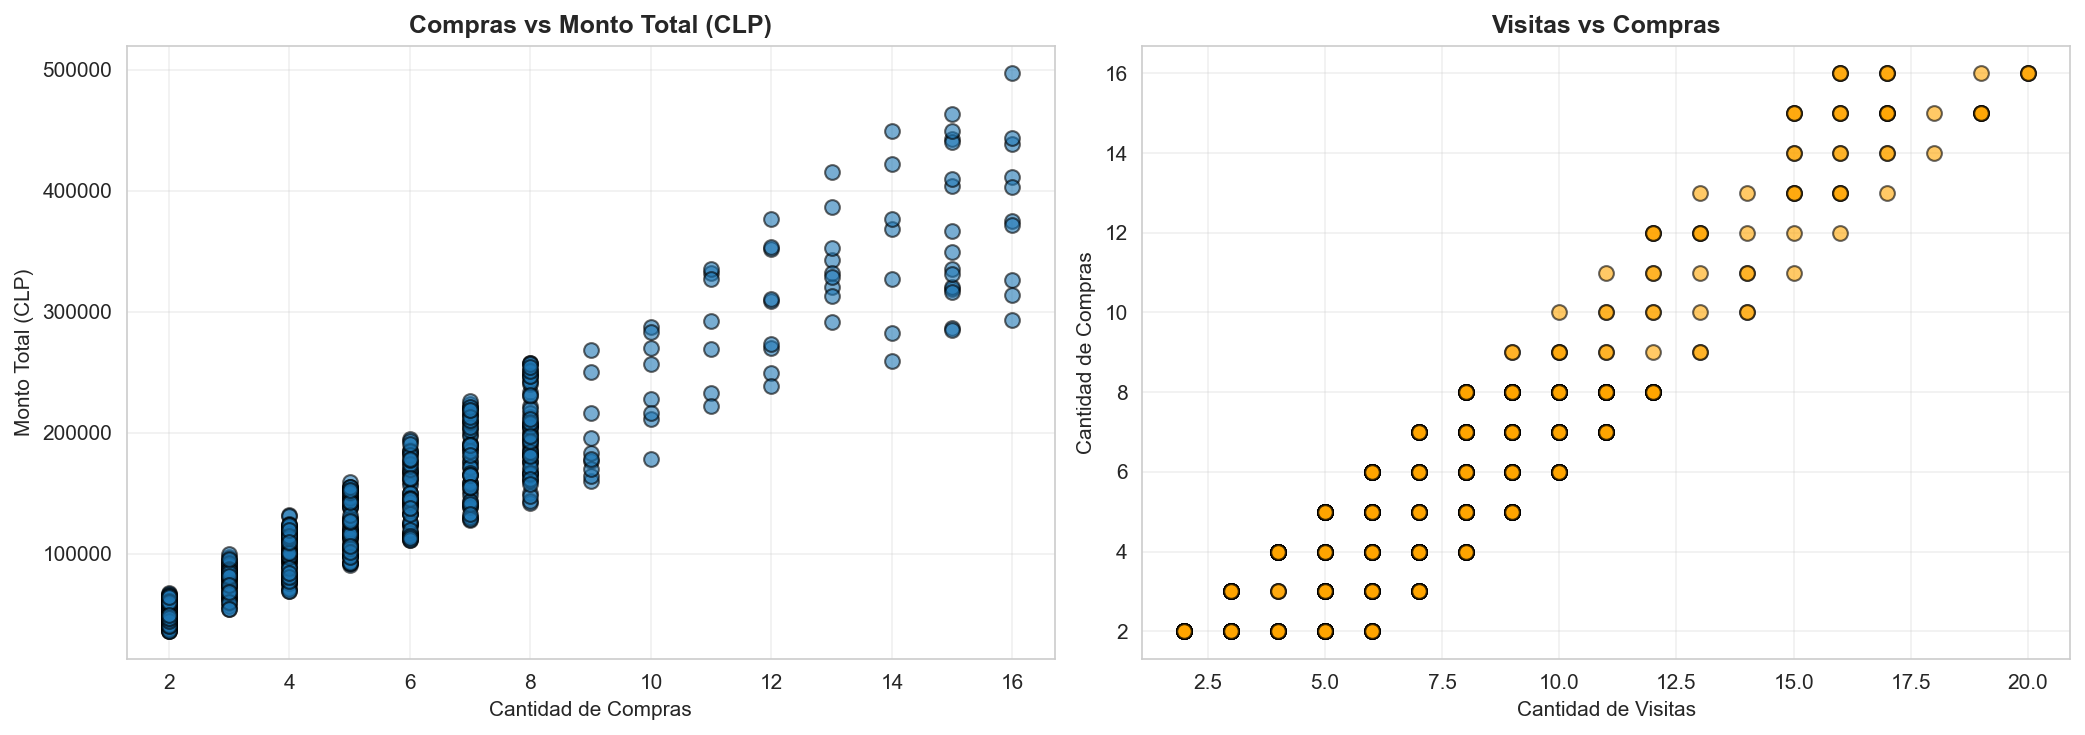

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['compras'], df['monto_total_clp'], alpha=0.6, edgecolor='k', s=50)
axes[0].set_title("Compras vs Monto Total (CLP)", fontweight='bold')
axes[0].set_xlabel("Cantidad de Compras")
axes[0].set_ylabel("Monto Total (CLP)")
axes[0].grid(alpha=0.3)

axes[1].scatter(df['visitas'], df['compras'], alpha=0.6, edgecolor='k', s=50, color='orange')
axes[1].set_title("Visitas vs Compras", fontweight='bold')
axes[1].set_xlabel("Cantidad de Visitas")
axes[1].set_ylabel("Cantidad de Compras")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Scatter_compras_vs_monto_total.png", dpi=150, bbox_inches='tight')
plt.show()

---
## Lección 4: REGRESIONES LINEALES

### 4.1 Modelo de Regresión Simple

In [12]:
X = df[['compras']]
y = df['monto_total_clp']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print(f"📈 PARÁMETROS DEL MODELO:")
print(f"   Intercepto (β0): {model.intercept_:,.2f}")
print(f"   Pendiente (β1):  {model.coef_[0]:,.2f}")
print(f"\n   Ecuación: y = {model.coef_[0]:.2f} × compras + {model.intercept_:.2f}")

📈 PARÁMETROS DEL MODELO:
   Intercepto (β0): 1,622.31
   Pendiente (β1):  24,741.91

   Ecuación: y = 24741.91 × compras + 1622.31


### 4.2 Métricas de Evaluación

In [13]:
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)

print(f"📊 MÉTRICAS DE DESEMPEÑO:")
print(f"   R² (coef. determinación):  {r2:.4f}  → Explica {r2*100:.1f}% de la varianza")
print(f"   MSE (error cuadrático):    {mse:,.2f}")
print(f"   RMSE:                      {rmse:,.2f}")
print(f"   MAE (error absoluto):      ${mae:,.2f} CLP")

📊 MÉTRICAS DE DESEMPEÑO:
   R² (coef. determinación):  0.8961  → Explica 89.6% de la varianza
   MSE (error cuadrático):    838,590,594.37
   RMSE:                      28,958.43
   MAE (error absoluto):      $22,113.25 CLP


**Interpretación:**
- R² cercano a 0.90 indica que el modelo explica casi el 90% de la variabilidad del monto gastado.
- El error promedio (MAE) nos dice cuánto nos desviamos en promedio de los valores reales.

### 4.3 Visualización del Modelo

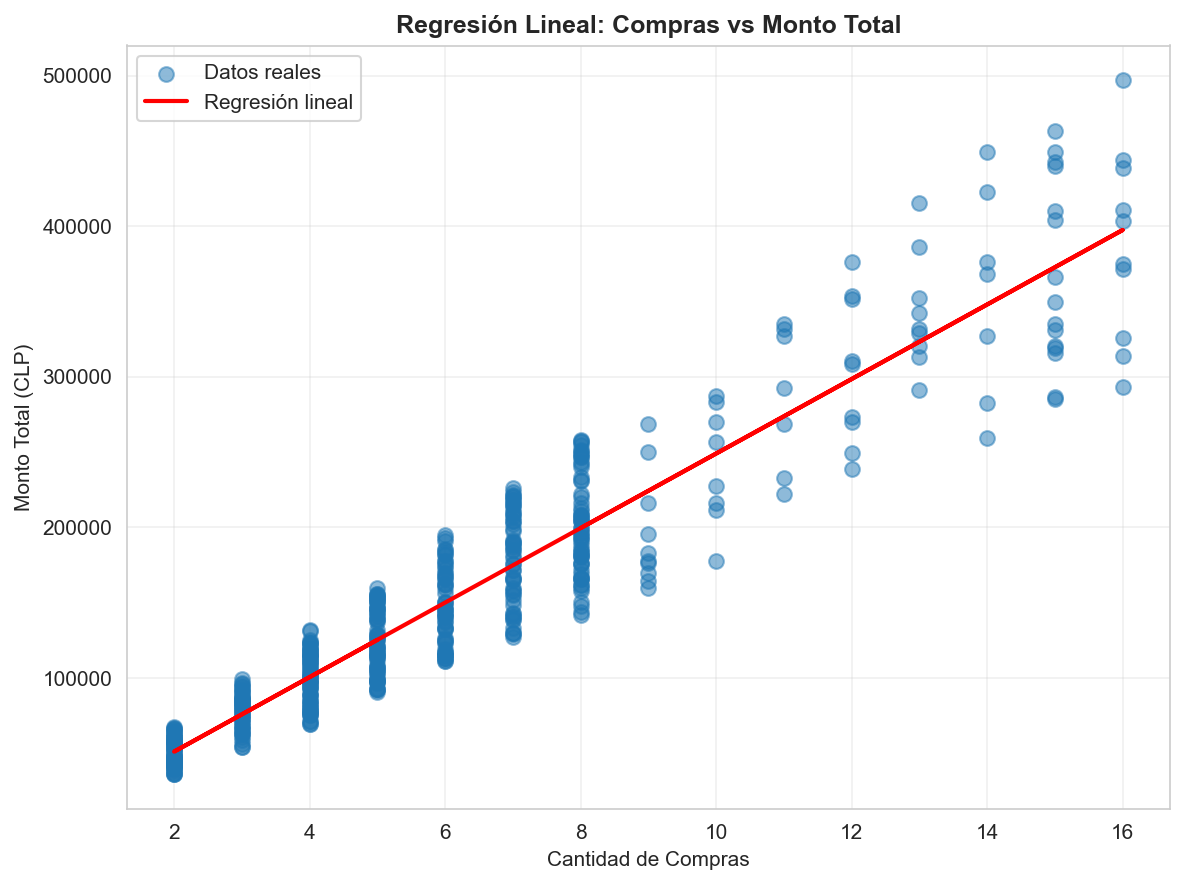

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.5, label='Datos reales', s=50)
plt.plot(X, y_pred, color='red', linewidth=2, label='Regresión lineal')
plt.title("Regresión Lineal: Compras vs Monto Total", fontweight='bold')
plt.xlabel("Cantidad de Compras")
plt.ylabel("Monto Total (CLP)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Regresion_lineal_compras_vs_monto_total.png", dpi=150, bbox_inches='tight')
plt.show()

---
## Lección 5: ANÁLISIS VISUAL DE DATOS (SEABORN)

### 5.1 Pairplot

El pairplot muestra todas las relaciones bivariadas entre variables numéricas.

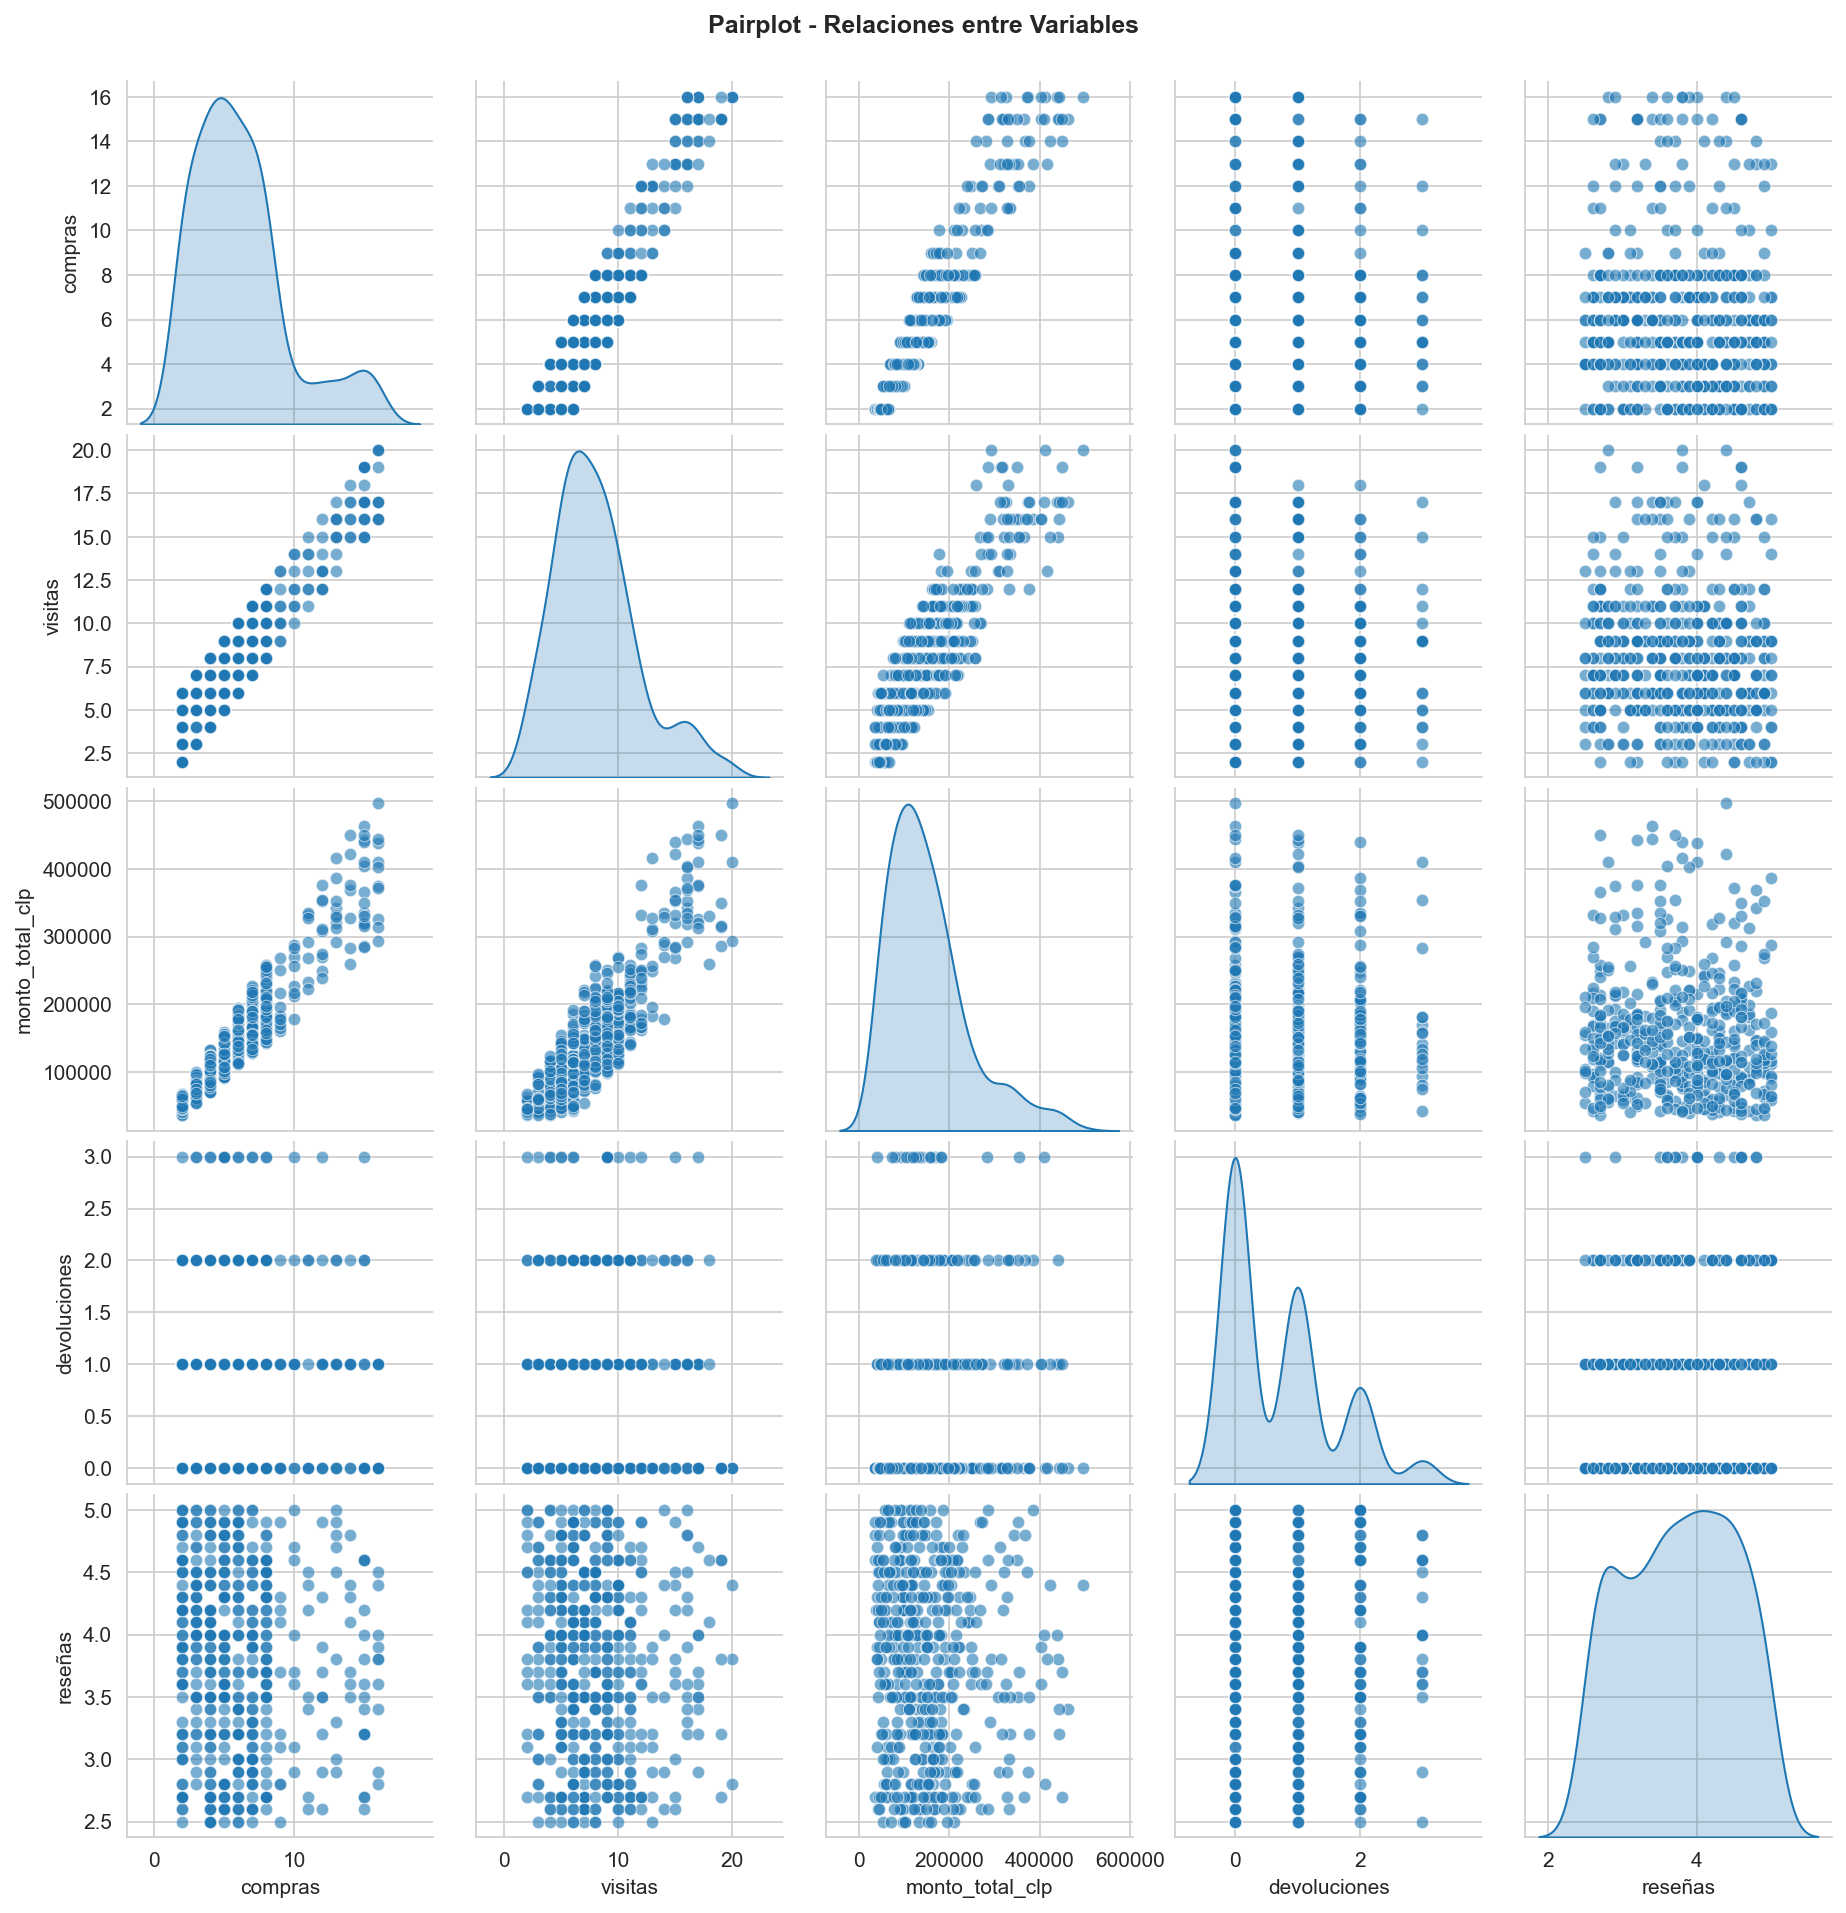

In [15]:
pairplot = sns.pairplot(df, diag_kind='kde', plot_kws={'alpha':0.6})
pairplot.fig.suptitle("Pairplot - Relaciones entre Variables", y=1.02, fontweight='bold')
plt.savefig("Pairplot.png", dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Jointplot

Combina scatterplot con histogramas marginales y línea de regresión.

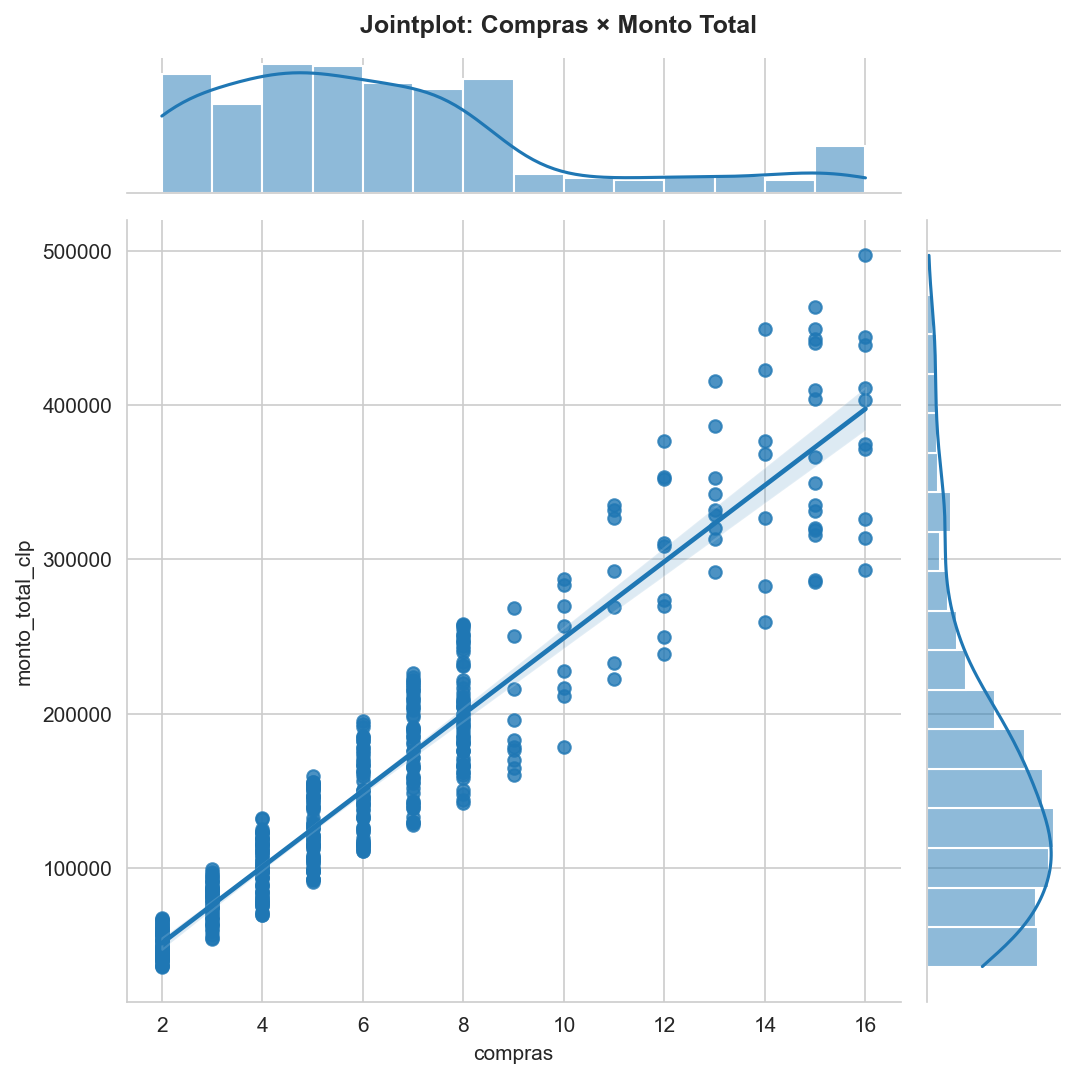

In [16]:
joint = sns.jointplot(data=df, x='compras', y='monto_total_clp', kind='reg', height=7)
joint.fig.suptitle("Jointplot: Compras × Monto Total", y=1.02, fontweight='bold')
plt.savefig("Jointplot_compras_x_monto_total.png", dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Violinplot

Muestra la distribución del monto total para cada nivel de compras.

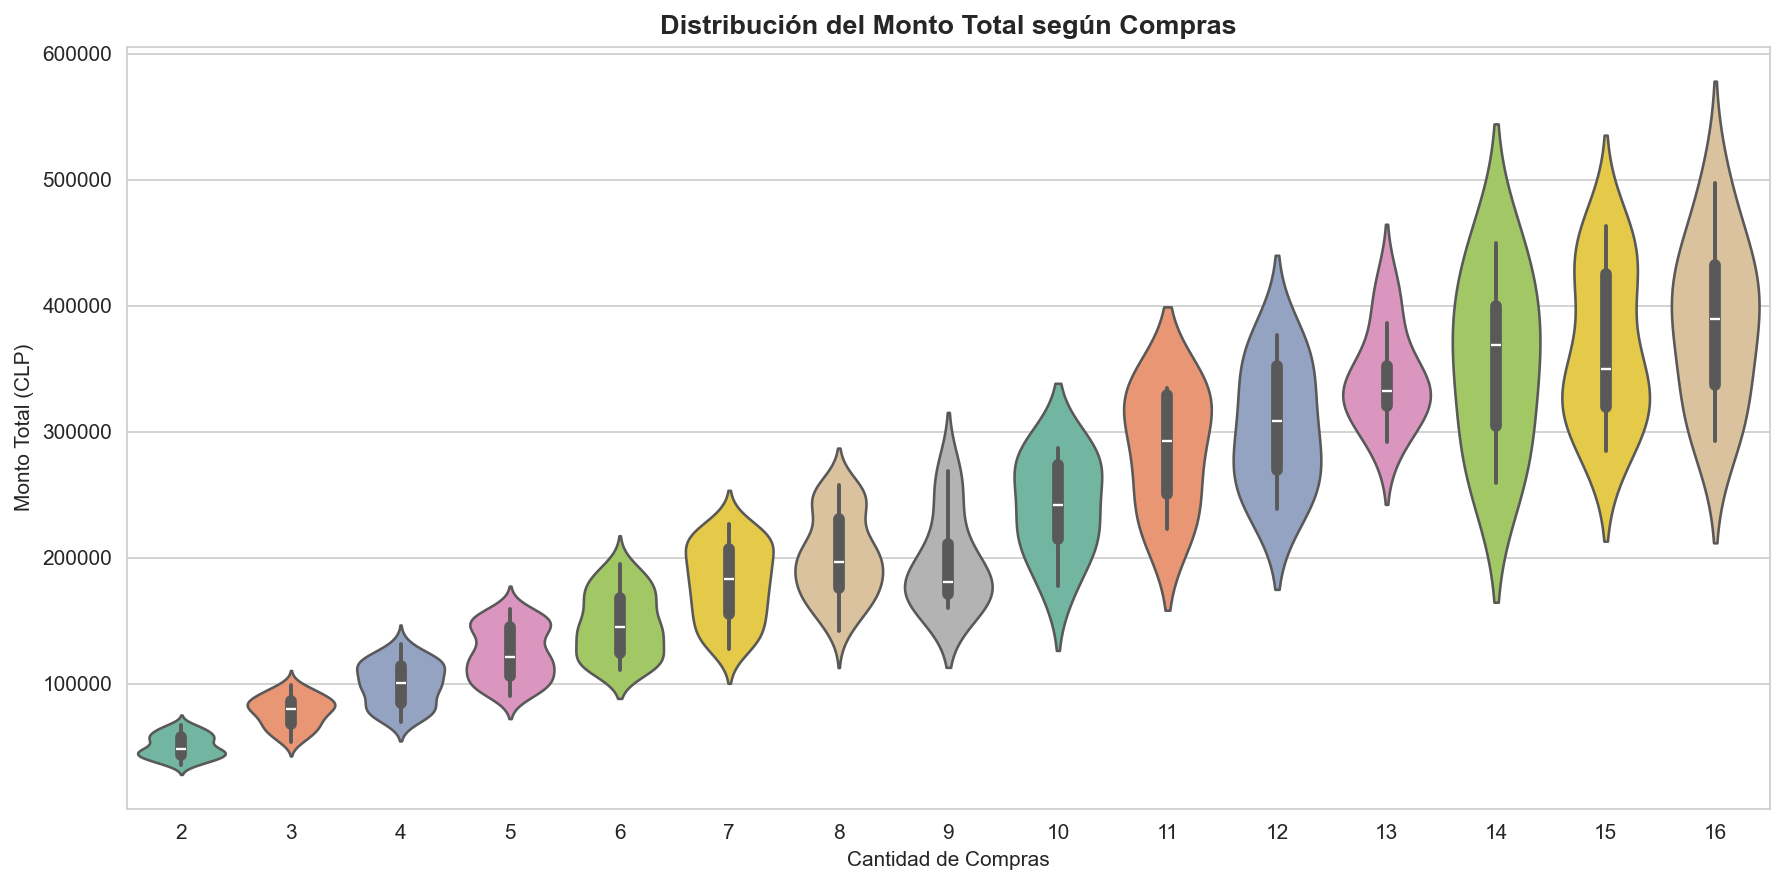

In [17]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='compras', y='monto_total_clp', palette='Set2')
plt.title("Distribución del Monto Total según Compras", fontweight='bold', fontsize=13)
plt.xlabel("Cantidad de Compras")
plt.ylabel("Monto Total (CLP)")
plt.tight_layout()
plt.savefig("Violinplot_compras_x_monto_total.png", dpi=150, bbox_inches='tight')
plt.show()

### 5.4 FacetGrid

Segmentación del análisis por categorías de reseñas.

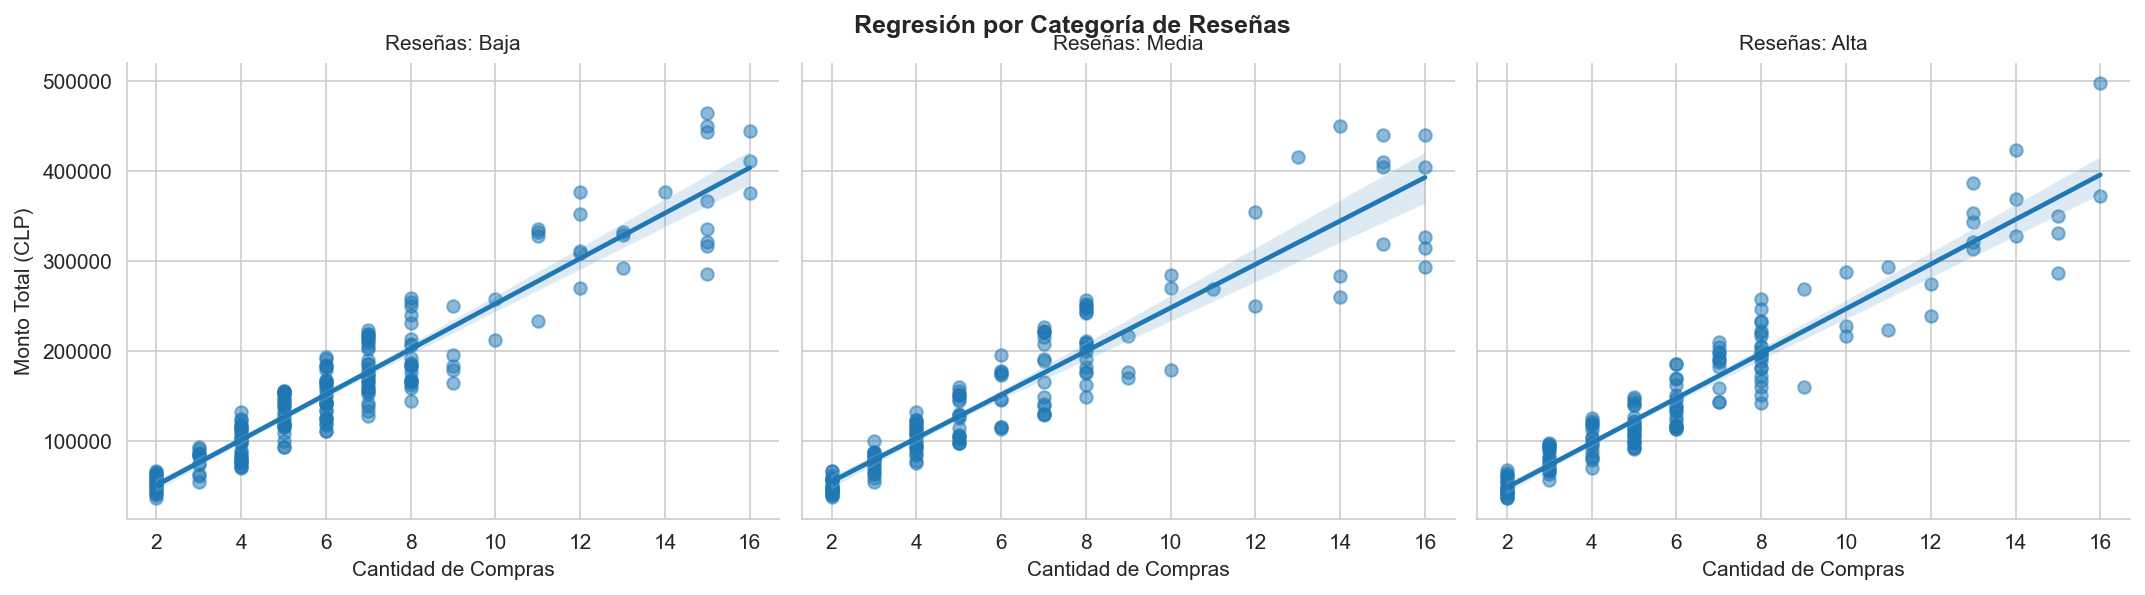

In [18]:
# Crear categorías de reseñas
df['categoria_reseña'] = pd.cut(df['reseñas'], bins=[0, 3.5, 4.2, 5.1], 
                                  labels=['Baja', 'Media', 'Alta'])

g = sns.FacetGrid(df, col='categoria_reseña', height=4, aspect=1.2)
g.map_dataframe(sns.regplot, x='compras', y='monto_total_clp', scatter_kws={'alpha':0.5})
g.set_axis_labels("Cantidad de Compras", "Monto Total (CLP)")
g.set_titles("Reseñas: {col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Regresión por Categoría de Reseñas", fontweight='bold')
plt.savefig("FacetGrid_categoria_reseña.png", dpi=150, bbox_inches='tight')
plt.show()

---
## Lección 6: LIBRERÍA MATPLOTLIB

### 6.1 Gráfico Personalizado Final

Creación de un gráfico con anotaciones, métricas y alta resolución para presentación.

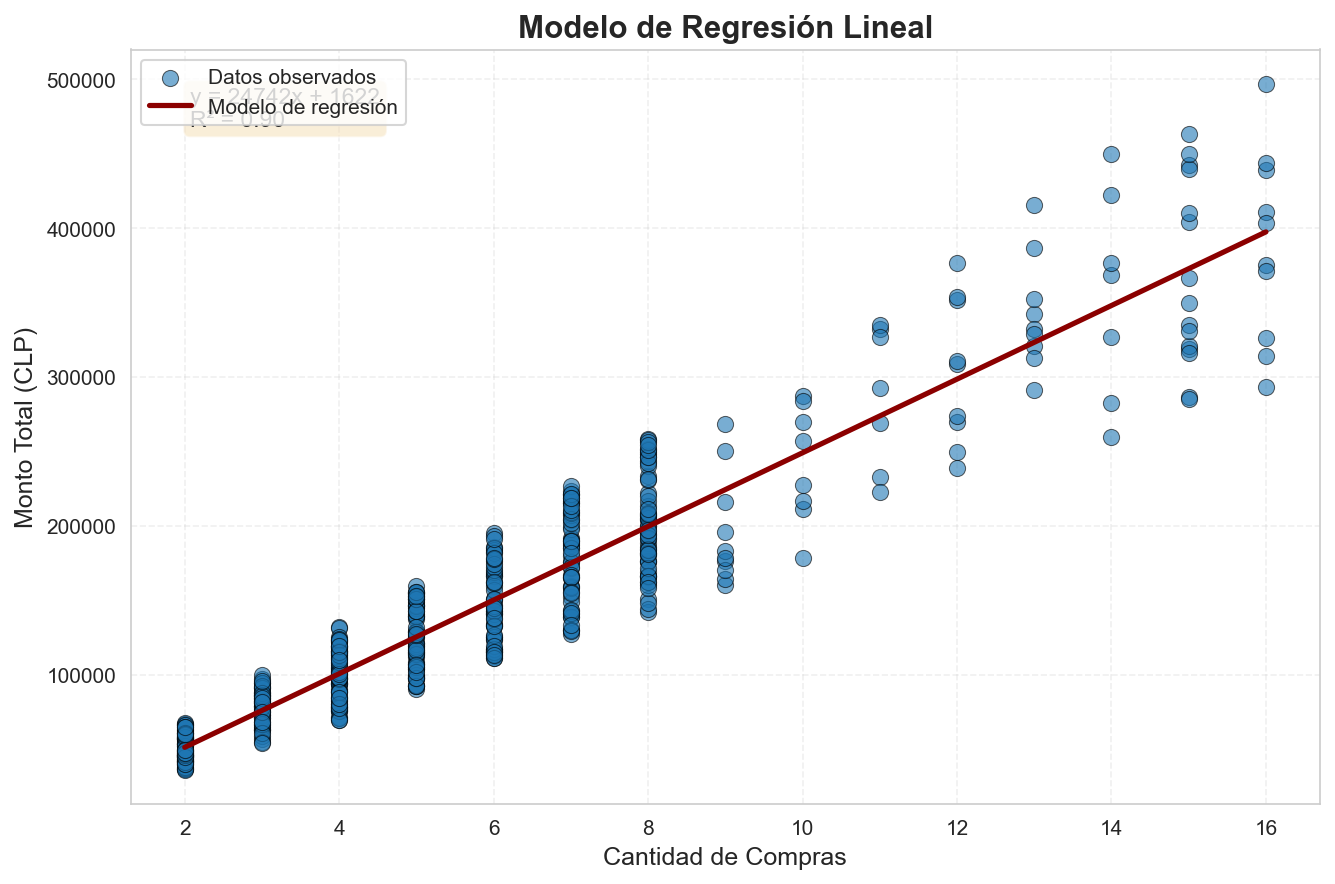

✅ Gráfico guardado en alta resolución (300 DPI)


In [19]:
# Ajustar modelo polinomial grado 1 (lineal)
coef = np.polyfit(df['compras'], df['monto_total_clp'], 1)
poly1d_fn = np.poly1d(coef)
x_vals = np.linspace(df['compras'].min(), df['compras'].max(), 100)

# Calcular R²
y_pred_poly = poly1d_fn(df['compras'])
r2_poly = r2_score(df['monto_total_clp'], y_pred_poly)

# Crear figura personalizada
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['compras'], df['monto_total_clp'], alpha=0.6, s=60, 
           edgecolor='k', linewidth=0.5, label='Datos observados')
ax.plot(x_vals, poly1d_fn(x_vals), color='darkred', linewidth=2.5, 
        label='Modelo de regresión')

ax.set_title("Modelo de Regresión Lineal", fontweight='bold', fontsize=15)
ax.set_xlabel("Cantidad de Compras", fontsize=12)
ax.set_ylabel("Monto Total (CLP)", fontsize=12)
ax.grid(alpha=0.3, linestyle='--')
ax.legend(loc='upper left', fontsize=10)

# Anotación con métricas del modelo
ax.text(0.05, 0.95, 
        f"y = {coef[0]:.0f}x + {coef[1]:.0f}\nR² = {r2_poly:.2f}",
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig("modelo_regresion_monto.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Gráfico guardado en alta resolución (300 DPI)")

### 6.2 Exportación de Gráficos

Todos los gráficos generados han sido guardados en formato PNG con resolución adecuada para presentaciones e informes técnicos.

---
## Conclusión General del Proyecto

Se realizó un análisis exploratorio de datos sobre comportamiento de clientes de ComercioYA, evaluando la relación entre:

- Compras
- Visitas
- Monto total
- Reseñas
- Devoluciones

### Hallazgos principales:

1. **Correlación fuerte** entre compras y monto_total_clp (r ≈ 0.95)
2. El modelo lineal explica aproximadamente el **90% de la variabilidad** del gasto (R² ≈ 0.90)
3. Cada compra adicional incrementa el gasto en aproximadamente **$24,700 CLP**
4. La distribución del monto presenta **asimetría positiva** (concentración en valores bajos)
5. Las **reseñas NO presentan impacto significativo** sobre el gasto
6. Existe una concentración de clientes en el rango de **2-8 compras**

### Conclusión final:

El **número de compras es el principal predictor del gasto acumulado del cliente**. Las estrategias comerciales deberían enfocarse en:
- Aumentar la frecuencia de compra mediante programas de fidelización
- Segmentar clientes de alto valor (>10 compras) para campañas personalizadas
- Incentivos basados en recompra más que en mejora de reseñas